In [12]:
print("hellolol")

hellolol


# Doing autoencoder project


# Goal
8760 hours of electricity prices. We look at a 24 hour window, and check for anomalies.

Autoencoder copy the input to the output. But, learns the output from the bottleneck/compressed data. If it cant reconstruct the original data, an anomaly is detected. Autoencoder is only trained on "normal" data.

LSTM learns the temporal patterns.


## What is this
LSTM autoencoder: for series anomaly detections. Long Short-Term Memory network

Data: synthetic, but realistic electricity spot prices with injected anomalies, modelled on Nordic/DK market structure.
    - I do synth data, to make sure that it actually spots the anomalies, before running on real data.

## Future additions:
Real market data. Check for public API availability, or historical data
Multi feature model, add volume demand, tempature as input
Streaming detection, replace batch prediction with real time sliding window over data stream
Model comparison: Benchmark against stat models?
CI/CD: automate retraining, model versioning


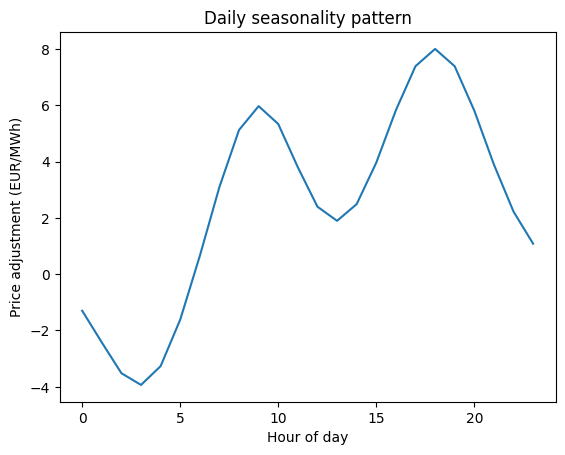

[-1.29836948 -2.42410986 -3.51686265 -3.9333459  -3.26636477 -1.61410019
  0.64938437  3.098343    5.12191738  5.9678345   5.33403963  3.79657087
  2.39683265  1.89467906  2.48791893  3.96067197  5.82231724  7.38694355
  8.00024039  7.38495313  5.80919392  3.89401814  2.22429841  1.08268227]


In [14]:
import numpy as np
import matplotlib.pyplot as plt

hour = np.arange(24)

daily = (
    6.0 * np.exp(-0.5 * ((hour - 9) / 2.0) ** 2)
    + 8.0 * np.exp(-0.5 * ((hour - 18) / 2.5) ** 2)
    - 4.0 * np.exp(-0.5 * ((hour - 3) / 2.0) ** 2)
)

plt.plot(hour, daily)
plt.xlabel("Hour of day")
plt.ylabel("Price adjustment (EUR/MWh)")
plt.title("Daily seasonality pattern")
plt.show()

print(daily)

Daily seasonality component: models the typical demand curve for nordic spot prices.

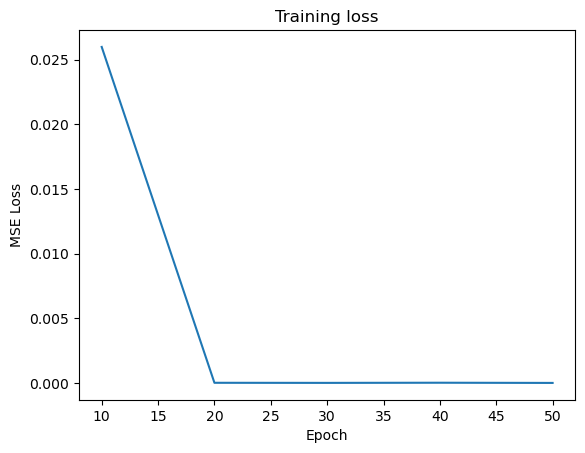

In [ ]:
import matplotlib.pyplot as plt

losses = [0.025989, 0.000017, 0.000010, 0.000022, 0.000007]  # training output
plt.plot(range(10, 51, 10), losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training loss")
plt.show()

## Results:
Model catches 98% of anomalies with 93% precision. 
Treshhold: Accept 5% of normal windows might be flagged as anomalous. Trading false positives for better recall
F1, 0.96: balance between precision and recall. 